In [27]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split
data=pd.read_csv("df_shuffle_before_smote_een.csv")
from tensorflow.keras.constraints import MaxNorm
from tensorflow.keras.layers import Dropout
data=data.drop_duplicates()
data= data.sample(frac = 1)
import tensorflow as tf
import keras 
from keras import regularizers
from tensorflow.keras.layers import Dense 

In [28]:
x=data.drop('Classe',axis=1)
y=data["Classe"] 
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
x = scaler.fit_transform(x)
x=pd.DataFrame(x)
# from sklearn.preprocessing import RobustScaler
# scaler = RobustScaler()
# x = scaler.fit_transform(x)
# x=pd.DataFrame(x)
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.1)
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_trains=x_train
X_tests=x_test



In [31]:
# from tensorflow.keras import initializers

# initializer = tf.keras.initializers.HeUniform()
from keras.layers import BatchNormalization
def build_model():
  model = keras.Sequential( name="MLP_model")
  return model 
# Build the model
model = build_model()
model.add(Dense(len(X_trains.iloc[0,:]),input_dim=len(X_trains.iloc[0,:]),activation='relu'))

model.add(Dense(100,activation="relu"))##400

model.add(Dense(64,activation="relu"))##60 RELU

model.add(Dense(64,activation="relu"))##60 RELU
model.add(Dense(1,activation="sigmoid"))
import pickle
weights = model.get_weights()
with open("w2.pkl", "wb") as f:
    pickle.dump(weights,f)
# with open("bestweight.pkl", "rb") as f:
#          weights = pickle.load(f)
# model.set_weights(weights)
    #optimizer = tf.keras.optimizers.RMSprop(0.001)
    #optimizer = tf.keras.optimizers.Adagrad(lr=0.001)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)#0.0001
    # optimizer = tf.keras.optimizers.Nadam(lr=0.001)
    # Compile the model
model.compile(loss="binary_crossentropy",optimizer=optimizer,metrics=["accuracy"])

In [64]:
# from sklearn.model_selection import StratifiedKFold
# k=3
# kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
# def build_model():
#   model = keras.Sequential( name="MLP_model")
#   return model 
# for train_index, val_index in kf.split(x_train, y_train):
#     # Get the training and validation data for this fold
#     X_train_fold, X_val_fold = X_trains.iloc[train_index], X_trains.iloc[val_index]
#     y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

#     # Build the model
#     model = build_model()
#     model.add(Dense(len(X_trains.iloc[0,:]),input_dim=len(X_trains.iloc[0,:]),activation='relu'))

#     model.add(Dense(100,activation="relu"))##400


#     model.add(Dense(64,activation="relu"))##60 RELU
#     model.add(Dense(8,activation="relu"))
#     model.add(Dense(1,activation="sigmoid"))
#     #optimizer = tf.keras.optimizers.RMSprop(0.001)
#     #optimizer = tf.keras.optimizers.Adagrad(lr=0.001)
#     optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)#0.0001
#     # optimizer = tf.keras.optimizers.Nadam(lr=0.001)
#     # Compile the model
#     model.compile(loss="binary_crossentropy",optimizer=optimizer,metrics=["accuracy"])
   
    
#     # Train the model
#     model.fit(X_train_fold, y_train_fold, epochs=2, batch_size=32, verbose=0)
#     import pickle
 
#     # model.set_weights(weights)
#     # Assuming you have a trained MLP model named 'mlp_model'
#     weights = model.get_weights()
#     # with open("bestweight.pkl", "rb") as f:
#     #     weights = pickle.load(f)
# #Save the weights using pickle
#     with open("w2.pkl", "wb") as f:
#       pickle.dump(weights, f)
#     # Evaluate the model on the validation fold
#     val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold)
#     print("Validation loss:", val_loss)
#     print("Validation accuracy:", val_accuracy)




# # Set the loaded weights to the model




# # model.summary()

In [33]:
early_stoppingg=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',min_delta=0.0001,patience=1)

In [35]:
EPOCHS = 50
# Store training stats loss="binary_crossentropy",optimizer="rmsprop",metrics=["accuracy"]
history = model.fit(X_trains, y_train, epochs=EPOCHS,
                    validation_split=0.2, verbose=1,batch_size=32)#callbacks=[early_stoppingg])




Epoch 1/50
11105/11105 [==============================] - 24s 2ms/step - loss: 0.3398 - accuracy: 0.8328 - val_loss: 0.3319 - val_accuracy: 0.8343
Epoch 2/50
11105/11105 [==============================] - 29s 3ms/step - loss: 0.3358 - accuracy: 0.8346 - val_loss: 0.3278 - val_accuracy: 0.8332
Epoch 3/50
11105/11105 [==============================] - 58s 5ms/step - loss: 0.3441 - accuracy: 0.8353 - val_loss: 0.3268 - val_accuracy: 0.8366
Epoch 4/50
11105/11105 [==============================] - 59s 5ms/step - loss: 0.3481 - accuracy: 0.8358 - val_loss: 0.3252 - val_accuracy: 0.8375
Epoch 5/50
11105/11105 [==============================] - 61s 5ms/step - loss: 0.3338 - accuracy: 0.8369 - val_loss: 0.3236 - val_accuracy: 0.8398
Epoch 6/50
11105/11105 [==============================] - 558s 50ms/step - loss: 0.3493 - accuracy: 0.8381 - val_loss: 0.3211 - val_accuracy: 0.8420
Epoch 7/50
11105/11105 [==============================] - 25s 2ms/step - loss: 0.3329 - accuracy: 0.8393 - val_loss:

(<Figure size 1000x500 with 2 Axes>,
 array([<AxesSubplot:title={'center':'Loss'}, xlabel='Epochs', ylabel='Loss'>,
        <AxesSubplot:title={'center':'Accuracy'}, xlabel='Epochs', ylabel='Accuracy'>],
       dtype=object))

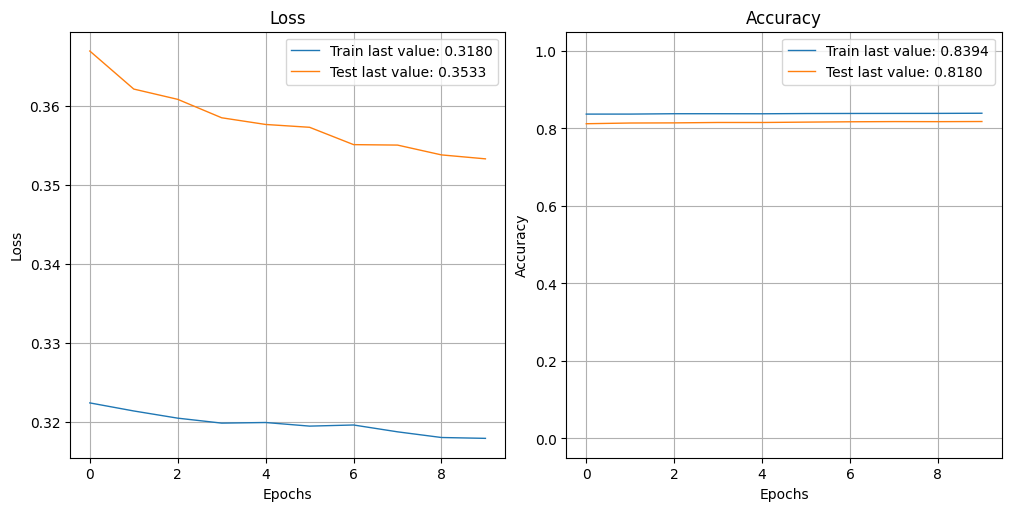

In [20]:
from plot_keras_history import show_history, plot_history
import matplotlib.pyplot as plt
plot_history(history)

In [21]:
prediction =model.predict(X_tests)


1543/1543 [==============================] - 1s 790us/step


In [22]:
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score
my_accuracy=accuracy_score(y_test,prediction.round())
print(my_accuracy)

0.8180289338250193


In [23]:
# from sklearn.metrics import plot_prediction
# test_predictions = model.predict(X_tests).flatten()
# plot_prediction(y_test, test_predictions)
for train_index, val_index in kf.split(x_train, y_train):
    # Get the training and validation data for this fold
    X_train_fold, X_val_fold = X_trains.iloc[train_index], X_trains.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    # Build the model
    model = build_model()

    # Compile the model
    model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

    # Train the model
    model.fit(X_train_fold, y_train_fold, epochs=10, batch_size=32, verbose=0)

    # Evaluate the model on the validation fold
    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold)
    print("Validation loss:", val_loss)
    print("Validation accuracy:", val_accuracy)


NameError: name 'kf' is not defined

1543/1543 [==============================] - 1s 744us/step
Sans compétences : ROC AUC=0.500
Régression Logistique : ROC AUC=0.913


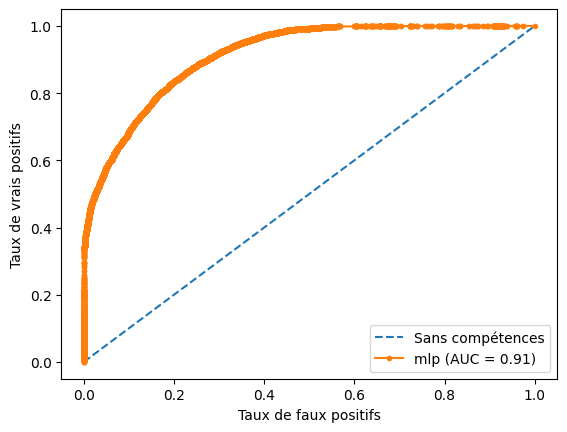

In [24]:
from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
ns_probs = [0 for _ in range(len(y_test))]
lr_probs = model.predict(X_tests)

# keep probabilities for the positive outcome only

# calculate scores

ns_auc = roc_auc_score(y_test, ns_probs)
lr_auc = roc_auc_score(y_test, lr_probs)
# summarize scores
print('Sans compétences : ROC AUC=%.3f' % (ns_auc))
print('Régression Logistique : ROC AUC=%.3f' % (lr_auc))
# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
# plot the roc curve for the model
pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='Sans compétences')
pyplot.plot(lr_fpr, lr_tpr, marker='.', label='mlp (AUC = {:.2f})'.format(lr_auc))

# axis labels
pyplot.xlabel('Taux de faux positifs')
pyplot.ylabel('Taux de vrais positifs')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()